In [1]:
import torch 

def reduce_rank_ps(A_cur, A_prev, U_0, S_0, V_0):
    # Check dimensions
    m, n = A_cur.shape
    r = U_0.shape[1]
    assert U_0.shape == (m, r)
    assert S_0.shape == (r, r)
    assert V_0.shape == (n, r)

    delta_A = A_cur - A_prev

    # Step 1: Update U
    K_cur = U_0 @ S_0 + delta_A @ V_0
    U_cur, S_hat = torch.linalg.qr(K_cur)

    # Step 2: Mid-step for S
    S_tild = S_hat - U_cur.T @ delta_A @ V_0

    # Step 3: Update V
    L_cur = V_0 @ S_tild.T + delta_A.T @ U_cur
    V_cur, S_cur_T = torch.linalg.qr(L_cur)

    # Return U, S (upper triangular), V
    return U_cur, S_cur_T.T, V_cur


def test_known_dynamics():
    """Test if PSI tracks a known low-rank dynamic system."""
    m, n, r = 5, 5, 2
    t = torch.linspace(0, 1, 10)
    
    # Ground truth: A(t) = U(t) S(t) V(t)^T, where U(t), V(t) evolve smoothly
    U_t = torch.eye(m)[:, :r] + 0.1 * torch.sin(torch.tensor(0)) * torch.randn(m, r)
    S_t = torch.diag(1.0 + 0.1 * torch.sin(torch.tensor(0)) * torch.randn(r)) 
    V_t = torch.eye(n)[:, :r] + 0.1 * torch.cos(torch.tensor(0)) * torch.randn(n, r)
    A_0 = U_t @ S_t @ V_t.mT  # (10, 5, 5)

    # Initialize PSI
    U_prev, S_prev, V_prev = U_t, S_t, V_t
    errors = []
    rank = 2
    A_cur = A_0

    for i in range(1, len(t)):
        A_prev = A_cur
        A_cur = A_prev + 0.01 * torch.randn(m, n)

        U_ps, S_ps, V_ps = reduce_rank_ps(A_cur, A_prev, U_prev, S_prev, V_prev)
        reconst_ps = U_ps @ S_ps @ V_ps.T

        U_svd, S_svd, V_svd = torch.linalg.svd(A_cur)
        reconst_svd = U_svd[:, :rank] @ torch.diag(S_svd[:rank]) @ V_svd.T[:rank, :]

        error = torch.norm(reconst_ps - reconst_svd)
        errors.append(error)
        U_prev, S_prev, V_prev = U_ps, S_ps, V_ps  # Update for next step

    avg_error = torch.mean(torch.tensor(errors))
    assert avg_error < 0.5, f"Average tracking error too high: {avg_error}"
    return errors

In [40]:
test_known_dynamics()

AssertionError: Average tracking error too high: 3.0907905101776123

In [28]:
torch.randn(5, 5)

tensor([[ 1.0487, -1.1299, -1.0960,  0.8287, -0.5834],
        [-0.5978,  0.4038, -0.0893,  0.0410, -0.1286],
        [-0.9435,  1.0513,  0.5764,  0.4356, -1.3699],
        [-0.2438,  0.9731,  2.6561,  0.0890,  1.9048],
        [-0.7118,  0.3549,  1.6811, -1.0441, -0.1580]])

In [6]:
import torch 
import pandas as pd

def reduce_rank_ps(delta_A, U_0, S_0, V_0):
    # Step 1: Update U
    K_cur = U_0 @ S_0 + delta_A @ V_0
    U_cur, S_hat = torch.linalg.qr(K_cur)

    # Step 2: Mid-step for S
    S_tild = S_hat - U_cur.T @ delta_A @ V_0

    # Step 3: Update V
    L_cur = V_0 @ S_tild.T + delta_A.T @ U_cur
    V_cur, S_cur_T = torch.linalg.qr(L_cur)

    # Return U, S (upper triangular), V
    return U_cur, S_cur_T.T, V_cur


def test_known_dynamics_with_gt_tracking():
    """Test PSI and SVD against ground truth matrices."""
    m, n, r = 5, 5, 2
    t = torch.linspace(0, 1, 10)    
    # Generate smooth ground truth evolution
    torch.manual_seed(42)  # For reproducibility
    U_gt = []
    S_gt = []
    V_gt = []
    A_gt = []
    
    for ti in t:
        U_t = torch.eye(m)[:, :r] + 0.1 * torch.sin(ti) * torch.randn(m, r)
        S_t = torch.diag(1.0 + 0.1 * torch.sin(ti) * torch.randn(r))
        V_t = torch.eye(n)[:, :r] + 0.1 * torch.cos(ti) * torch.randn(n, r)
        A_t = U_t @ S_t @ V_t.T
        
        U_gt.append(U_t)
        S_gt.append(S_t)
        V_gt.append(V_t)
        A_gt.append(A_t)
    
    # Initialize with first ground truth
    U_prev, S_prev, V_prev = U_gt[0], S_gt[0], V_gt[0]
    
    errors_ps_vs_gt = []
    errors_svd_vs_gt = []
    errors_ps_vs_observed = []
    errors_svd_vs_observed = []
    
    for i in range(1, len(t)):
        # Ground truth at current time
        A_gt_current = A_gt[i]
        
        # Observed (noisy) matrix
        A_observed = A_gt_current + 0.01 * torch.randn(m, n)
        A_prev_observed = A_gt[i-1] + 0.01 * torch.randn(m, n) if i > 0 else A_observed
        
        # PSI reconstruction
        update = A_observed - A_prev_observed
        U_ps, S_ps, V_ps = reduce_rank_ps(update, U_prev, S_prev, V_prev)
        reconst_ps = U_ps @ S_ps @ V_ps.T
        
        # SVD reconstruction
        U_svd, S_svd, V_svd = torch.linalg.svd(A_observed)
        reconst_svd = U_svd[:, :r] @ torch.diag(S_svd[:r]) @ V_svd[:r, :] 
        
        # Errors against ground truth
        error_ps_vs_gt = torch.norm(reconst_ps - A_gt_current).item()
        error_svd_vs_gt = torch.norm(reconst_svd - A_gt_current).item()
        
        # Errors against observed (noisy) matrix
        error_ps_vs_observed = torch.norm(reconst_ps - A_observed).item()
        error_svd_vs_observed = torch.norm(reconst_svd - A_observed).item()
        
        errors_ps_vs_gt.append(error_ps_vs_gt)
        errors_svd_vs_gt.append(error_svd_vs_gt)
        errors_ps_vs_observed.append(error_ps_vs_observed)
        errors_svd_vs_observed.append(error_svd_vs_observed)
        
        # Update for next iteration
        U_prev, S_prev, V_prev = U_ps, S_ps, V_ps
    
    # Calculate averages
    avg_ps_vs_gt = torch.mean(torch.tensor(errors_ps_vs_gt)).item()
    avg_svd_vs_gt = torch.mean(torch.tensor(errors_svd_vs_gt)).item()
    avg_ps_vs_observed = torch.mean(torch.tensor(errors_ps_vs_observed)).item()
    avg_svd_vs_observed = torch.mean(torch.tensor(errors_svd_vs_observed)).item()
    
    print(f"Average PSI error vs GT: {avg_ps_vs_gt:.4f}")
    print(f"Average SVD error vs GT: {avg_svd_vs_gt:.4f}")
    print(f"Average PSI error vs observed: {avg_ps_vs_observed:.4f}")
    print(f"Average SVD error vs observed: {avg_svd_vs_observed:.4f}")
    
    return {
        't': range(0, len(errors_ps_vs_gt)),
        'ps_vs_gt': errors_ps_vs_gt,
        'svd_vs_gt': errors_svd_vs_gt,
        'ps_vs_observed': errors_ps_vs_observed,
        'svd_vs_observed': errors_svd_vs_observed,
        # 'averages': {
        #     'ps_vs_gt': avg_ps_vs_gt,
        #     'svd_vs_gt': avg_svd_vs_gt,
        #     'ps_vs_observed': avg_ps_vs_observed,
        #     'svd_vs_observed': avg_svd_vs_observed
        # }
    }

# Run the test
results = test_known_dynamics_with_gt_tracking()

Average PSI error vs GT: 0.1101
Average SVD error vs GT: 0.0406
Average PSI error vs observed: 0.1081
Average SVD error vs observed: 0.0324


Average PSI error vs GT: 0.1101
Average SVD error vs GT: 0.0406
Average PSI error vs observed: 0.1081
Average SVD error vs observed: 0.0324


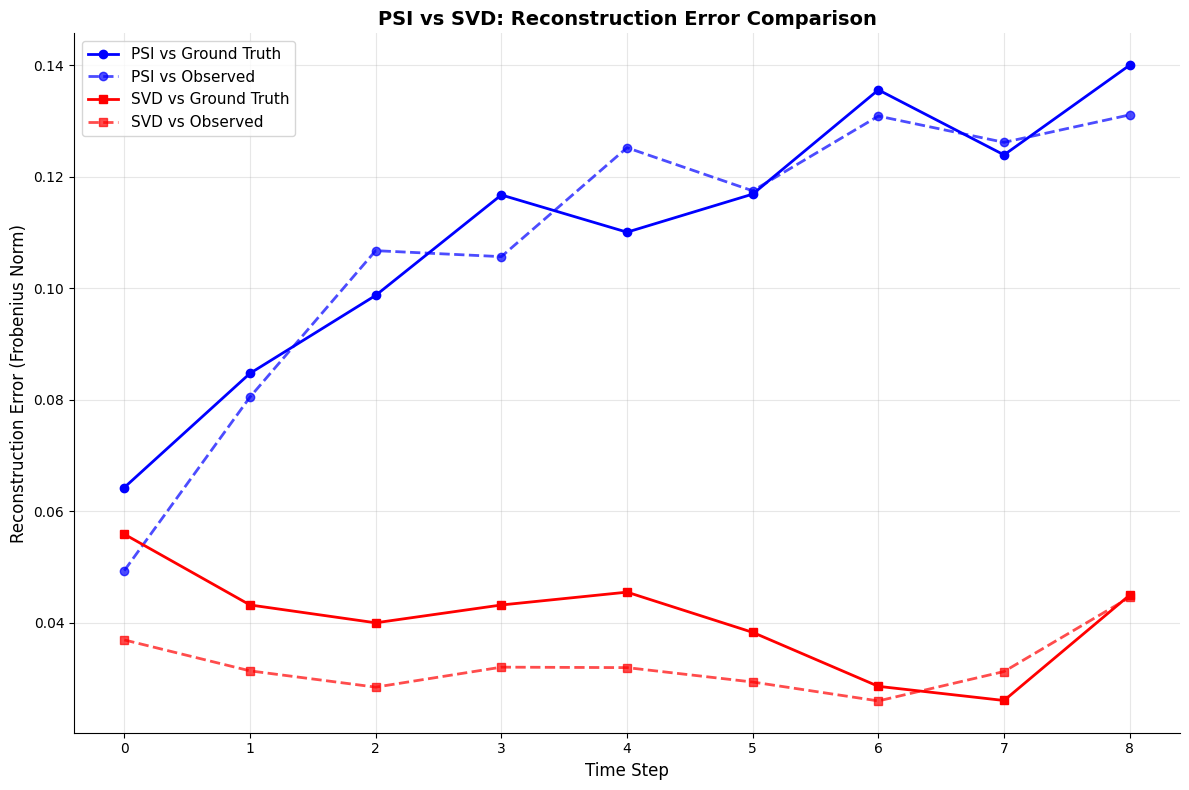

In [81]:
import matplotlib.pyplot as plt
import pandas as pd

# Run your test and get results
results = test_known_dynamics_with_gt_tracking()
df = pd.DataFrame(results)

# Create the plot
plt.figure(figsize=(12, 8))
plt.plot(df['t'], df['ps_vs_gt'], 'b-', linewidth=2, label='PSI vs Ground Truth', marker='o')
plt.plot(df['t'], df['ps_vs_observed'], 'b--', linewidth=2, label='PSI vs Observed', marker='o', alpha=0.7)
plt.plot(df['t'], df['svd_vs_gt'], 'r-', linewidth=2, label='SVD vs Ground Truth', marker='s')
plt.plot(df['t'], df['svd_vs_observed'], 'r--', linewidth=2, label='SVD vs Observed', marker='s', alpha=0.7)

plt.xlabel('Time Step', fontsize=12)
plt.ylabel('Reconstruction Error (Frobenius Norm)', fontsize=12)
plt.title('PSI vs SVD: Reconstruction Error Comparison', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Add some styling
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.show()


tensor([10.0244,  4.3438,  3.5668])
tensor([10.1676,  4.3969,  3.9610])
tensor([11.8438,  6.4844,  4.1040])
tensor([12.4288,  6.7243,  4.1266])
tensor([11.4732,  7.1153,  5.3380])
tensor([12.3105,  7.0757,  5.4137])
tensor([13.3247,  9.2416,  6.1598])
tensor([14.4745,  9.2332,  6.2098])
tensor([14.6939,  9.4004,  6.5895])
tensor([16.2707, 10.5801,  7.4942])
tensor([15.8819,  9.9175,  7.5687])
tensor([18.3560, 11.6192,  9.9598])
tensor([15.8955, 10.4568,  8.0518])
tensor([18.4102, 11.6955, 10.4584])
tensor([16.2818, 11.5294,  8.0516])
tensor([18.7596, 11.9916, 11.2885])
tensor([16.3577, 11.5295,  8.3452])
tensor([18.7763, 12.2347, 11.4297])
tensor([16.3341, 11.6665,  8.3713])
tensor([18.8686, 12.2202, 11.5689])


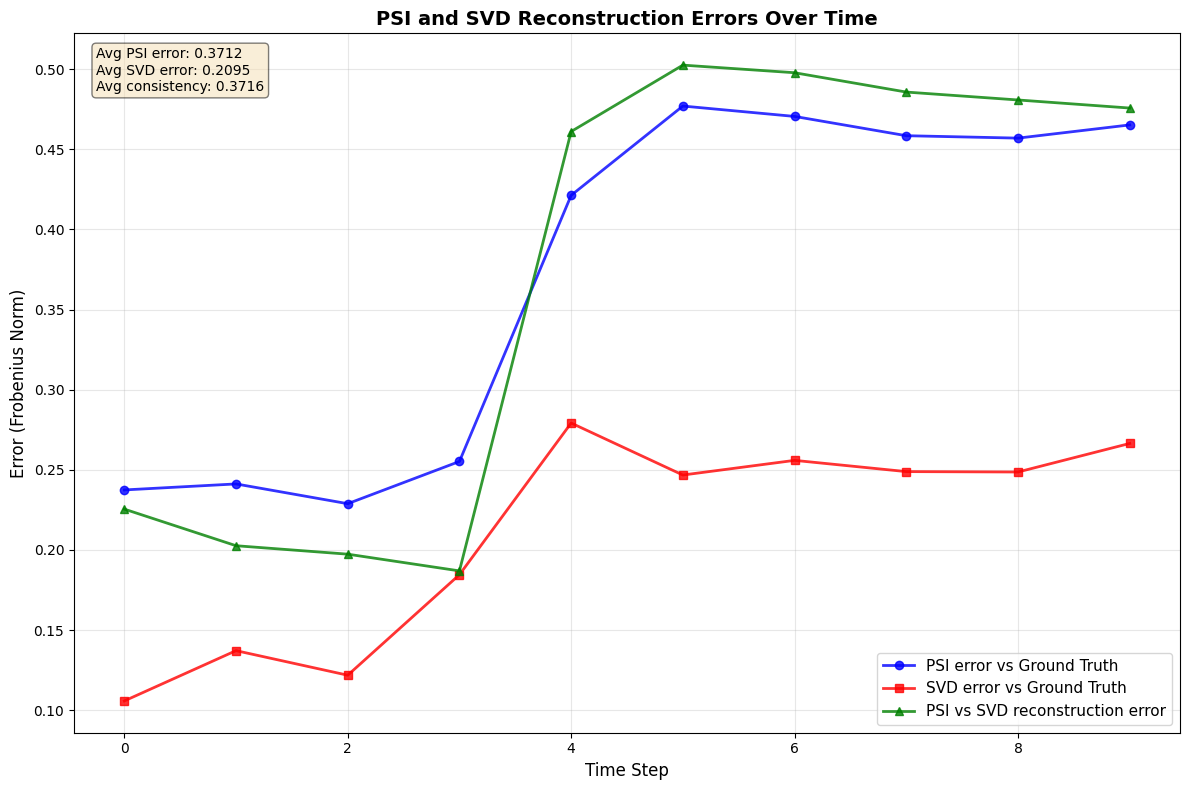

In [ ]:
import torch
import matplotlib.pyplot as plt


def reduce_rank_ps(delta_A, U_0, S_0, V_0):
    # Step 1: Update U
    K_cur = U_0 @ S_0 + delta_A @ V_0
    U_cur, S_hat = torch.linalg.qr(K_cur)

    # Step 2: Mid-step for S
    S_tild = S_hat - U_cur.T @ delta_A @ V_0

    # Step 3: Update V
    L_cur = V_0 @ S_tild.T + delta_A.T @ U_cur
    V_cur, S_cur_T = torch.linalg.qr(L_cur)

    # Return U, S (upper triangular), V
    return U_cur, S_cur_T.T, V_cur


def test_dynamics_with_gt_tracking():
    """Test PSI and SVD against ground truth matrices."""
    m, n,  = 10, 10
    seeds = [0, 100, 42]

    ranks = [3, 4, 5]

    for r in ranks:
        for seed in seeds:
            # Initialize with rank-r matrix
            gt_matrix = torch.randn(m, r) @ torch.randn(r, n)  # Ensure low-rank start
    
            # Get initial rank-r SVD factors
            U_full, S_full, V_full = torch.linalg.svd(gt_matrix)
            U = U_full[:, :r]           # [m, r]
            S = torch.diag(S_full[:r])  # [r, r] 
            V = V_full.T[:, :r]         # [n, r]
    
            gt_matrix_upd = gt_matrix.clone()
    
            # Store errors for plotting
            psi_errors = []
            svd_errors = []
            consistency_errors = []
    
            for i, t in enumerate(torch.linspace(0, 1, 10)):
                g = torch.randn(1, n)
                update = g.T @ g + 
    
                U, S, V = reduce_rank_ps(update, U, S, V,)
                # print(U.shape)
                # print(S.shape)
                # print(V.shape)
                # ps_recon = U[:,:r] @ S[:r] @ V.T[:r, :]
                ps_recon = U @ S @ V.T
                _, ps_eigen_vals, _ = torch.linalg.svd(S)
    
                gt_matrix_upd += update
    
                U_full, S_full, V_full = torch.linalg.svd(gt_matrix_upd)
                svd_recon = U_full[:, :r] @ torch.diag(S_full[:r]) @ V_full[:r, :]
    
                print(ps_eigen_vals[:r])
                print(S_full[:r])
    
                psi_error = torch.norm(ps_recon - gt_matrix_upd).item() / torch.norm(gt_matrix_upd).item()
                svd_error = torch.norm(svd_recon - gt_matrix_upd).item() / torch.norm(gt_matrix_upd).item()
                consistency_error = torch.norm(ps_recon - svd_recon).item() / torch.norm(gt_matrix_upd).item()
    
                # Store errors
                psi_errors.append(psi_error)
                svd_errors.append(svd_error)
                consistency_errors.append(consistency_error)
    
                # print(f"Step {i}: PSI error = {psi_error:.4f}, SVD error = {svd_error:.4f}")
                # print(f"         PSI vs SVD reconstruction: {consistency_error:.4f}")
    
            # Return errors for plotting
        return psi_errors, svd_errors, consistency_errors

def plot_psi_results(psi_errors, svd_errors, consistency_errors):
    """Plot PSI and SVD reconstruction errors over time."""
    steps = range(len(psi_errors))
    
    plt.figure(figsize=(12, 8))
    
    # Plot the three error metrics
    plt.plot(steps, psi_errors, 'b-o', linewidth=2, markersize=6, 
             label='PSI error vs Ground Truth', alpha=0.8)
    plt.plot(steps, svd_errors, 'r-s', linewidth=2, markersize=6, 
             label='SVD error vs Ground Truth', alpha=0.8)
    plt.plot(steps, consistency_errors, 'g-^', linewidth=2, markersize=6, 
             label='PSI vs SVD reconstruction error', alpha=0.8)
    
    # Formatting
    plt.xlabel('Time Step', fontsize=12)
    plt.ylabel('Error (Frobenius Norm)', fontsize=12)
    plt.title('PSI and SVD Reconstruction Errors Over Time', fontsize=14, fontweight='bold')
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    
    # Add some statistics as text
    avg_psi = sum(psi_errors) / len(psi_errors)
    avg_svd = sum(svd_errors) / len(svd_errors)
    avg_consistency = sum(consistency_errors) / len(consistency_errors)
    
    plt.text(0.02, 0.98, f'Avg PSI error: {avg_psi:.4f}\nAvg SVD error: {avg_svd:.4f}\nAvg consistency: {avg_consistency:.4f}', 
             transform=plt.gca().transAxes, fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.show()

# Usage example:
psi_errors, svd_errors, consistency_errors = test_dynamics_with_gt_tracking()
plot_psi_results(psi_errors, svd_errors, consistency_errors)


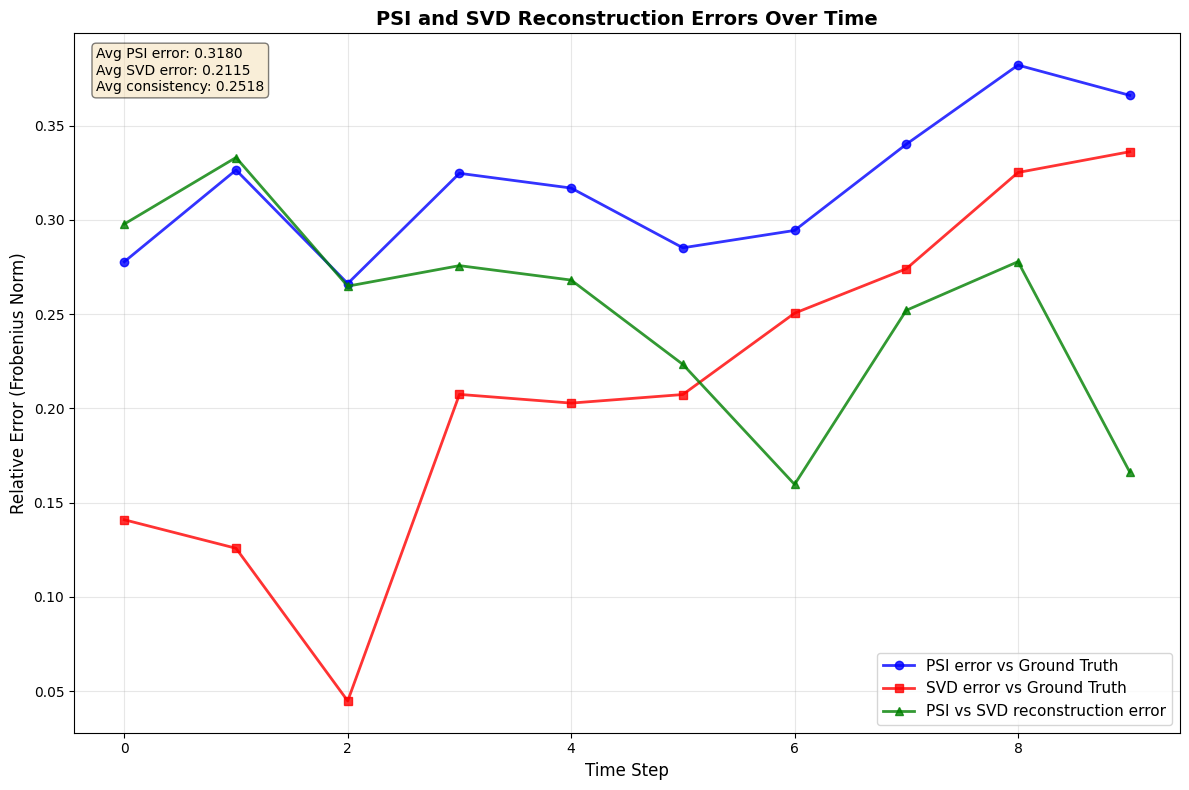

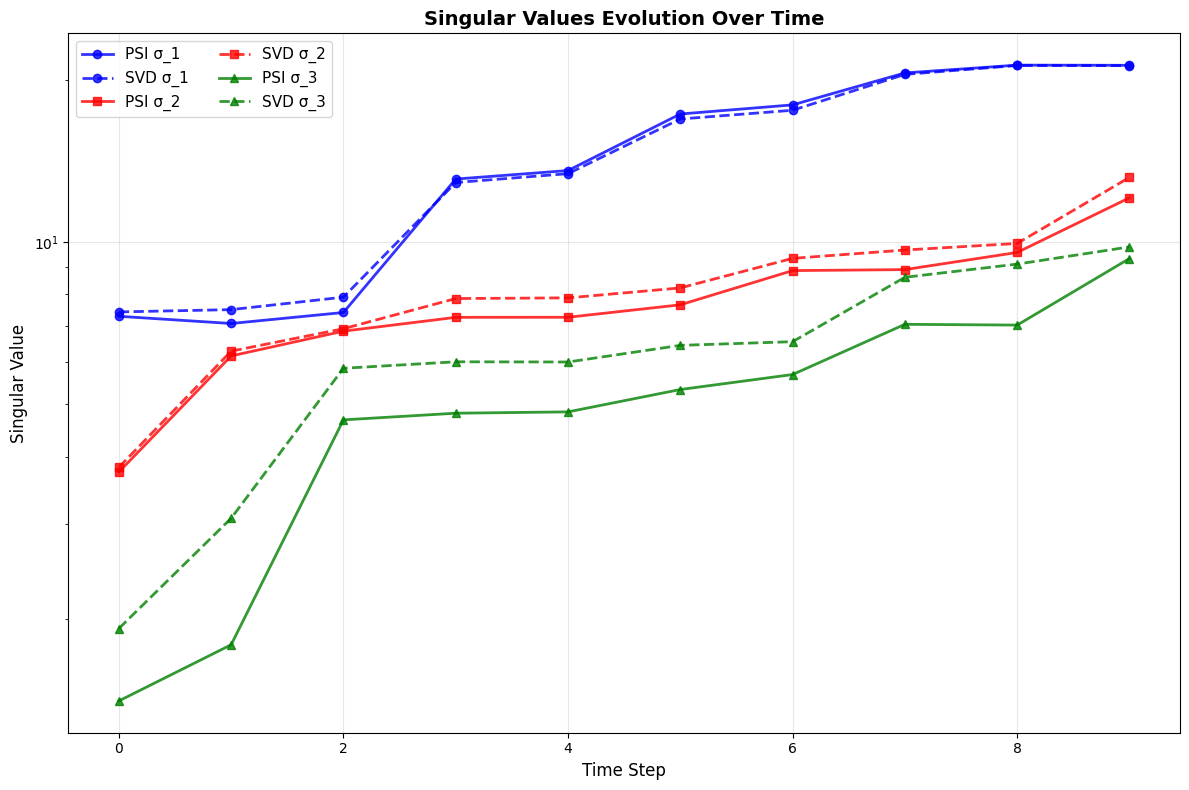

In [76]:
import torch
import matplotlib.pyplot as plt


def reduce_rank_ps(delta_A, U_0, S_0, V_0):
    # Step 1: Update U
    K_cur = U_0 @ S_0 + delta_A @ V_0
    U_cur, S_hat = torch.linalg.qr(K_cur)

    # Step 2: Mid-step for S
    S_tild = S_hat - U_cur.T @ delta_A @ V_0

    # Step 3: Update V
    L_cur = V_0 @ S_tild.T + delta_A.T @ U_cur
    V_cur, S_cur_T = torch.linalg.qr(L_cur)

    # Return U, S (upper triangular), V
    return U_cur, S_cur_T.T, V_cur


def test_dynamics_with_gt_tracking():
    """Test PSI and SVD against ground truth matrices and collect singular values."""
    m, n, r = 5, 5, 3

    # Initialize with rank-r matrix
    gt_matrix = torch.randn(m, r) @ torch.randn(r, n)  # Ensure low-rank start
    
    # Get initial rank-r SVD factors
    U_full, S_full, V_full = torch.linalg.svd(gt_matrix)
    U = U_full[:, :r]           # [m, r]
    S = torch.diag(S_full[:r])  # [r, r] 
    V = V_full.T[:, :r]         # [n, r]
    
    gt_matrix_upd = gt_matrix.clone()

    # Store errors and singular values for plotting
    psi_errors = []
    svd_errors = []
    consistency_errors = []
    psi_singular_values = []
    svd_singular_values = []

    for i, t in enumerate(torch.linspace(0, 1, 10)):
        g = torch.randn(1, n)
        update = g.T @ g
        
        U, S, V = reduce_rank_ps(update, U, S, V)
        ps_recon = U @ S @ V.T
        
        # Extract PSI singular values from S matrix
        _, ps_svals, _ = torch.linalg.svd(S)

        gt_matrix_upd += update
        
        U_full, S_full, V_full = torch.linalg.svd(gt_matrix_upd)
        svd_recon = U_full[:, :r] @ torch.diag(S_full[:r]) @ V_full[:r, :]

        psi_error = torch.norm(ps_recon - gt_matrix_upd).item() / torch.norm(gt_matrix_upd).item()
        svd_error = torch.norm(svd_recon - gt_matrix_upd).item() / torch.norm(gt_matrix_upd).item()
        consistency_error = torch.norm(ps_recon - svd_recon).item() / torch.norm(gt_matrix_upd).item()
        
        # Store errors
        psi_errors.append(psi_error)
        svd_errors.append(svd_error)
        consistency_errors.append(consistency_error)
        
        # Store singular values
        psi_singular_values.append(ps_svals[:r].tolist())
        svd_singular_values.append(S_full[:r].tolist())
    
    # Return errors and singular values for plotting
    return psi_errors, svd_errors, consistency_errors, psi_singular_values, svd_singular_values


def plot_psi_results(psi_errors, svd_errors, consistency_errors, psi_singular_values, svd_singular_values):
    """Plot PSI and SVD reconstruction errors and singular values over time."""
    steps = range(len(psi_errors))
    
    # Plot 1: Error metrics
    plt.figure(figsize=(12, 8))
    
    plt.plot(steps, psi_errors, 'b-o', linewidth=2, markersize=6, 
             label='PSI error vs Ground Truth', alpha=0.8)
    plt.plot(steps, svd_errors, 'r-s', linewidth=2, markersize=6, 
             label='SVD error vs Ground Truth', alpha=0.8)
    plt.plot(steps, consistency_errors, 'g-^', linewidth=2, markersize=6, 
             label='PSI vs SVD reconstruction error', alpha=0.8)
    
    plt.xlabel('Time Step', fontsize=12)
    plt.ylabel('Relative Error (Frobenius Norm)', fontsize=12)
    plt.title('PSI and SVD Reconstruction Errors Over Time', fontsize=14, fontweight='bold')
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    
    # Add statistics
    avg_psi = sum(psi_errors) / len(psi_errors)
    avg_svd = sum(svd_errors) / len(svd_errors)
    avg_consistency = sum(consistency_errors) / len(consistency_errors)
    
    plt.text(0.02, 0.98, f'Avg PSI error: {avg_psi:.4f}\nAvg SVD error: {avg_svd:.4f}\nAvg consistency: {avg_consistency:.4f}', 
             transform=plt.gca().transAxes, fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.show()
    
    # Plot 2: Singular values
    plt.figure(figsize=(12, 8))
    
    colors = ['blue', 'red', 'green']
    markers = ['o', 's', '^']
    
    for i in range(min(3, len(psi_singular_values[0]))):  # Plot up to 3 singular values
        psi_vals = [sv[i] for sv in psi_singular_values]
        svd_vals = [sv[i] for sv in svd_singular_values]
        
        plt.plot(steps, psi_vals, color=colors[i], marker=markers[i], linestyle='-', 
                linewidth=2, markersize=6, label=f'PSI σ_{i+1}', alpha=0.8)
        plt.plot(steps, svd_vals, color=colors[i], marker=markers[i], linestyle='--', 
                linewidth=2, markersize=6, label=f'SVD σ_{i+1}', alpha=0.8)
    
    plt.xlabel('Time Step', fontsize=12)
    plt.ylabel('Singular Value', fontsize=12)
    plt.title('Singular Values Evolution Over Time', fontsize=14, fontweight='bold')
    plt.legend(fontsize=11, ncol=2)
    plt.grid(True, alpha=0.3)
    plt.yscale('log')  # Log scale often better for singular values
    
    plt.tight_layout()
    plt.show()


# Usage example:
psi_errors, svd_errors, consistency_errors, psi_singular_values, svd_singular_values = test_dynamics_with_gt_tracking()
plot_psi_results(psi_errors, svd_errors, consistency_errors, psi_singular_values, svd_singular_values)


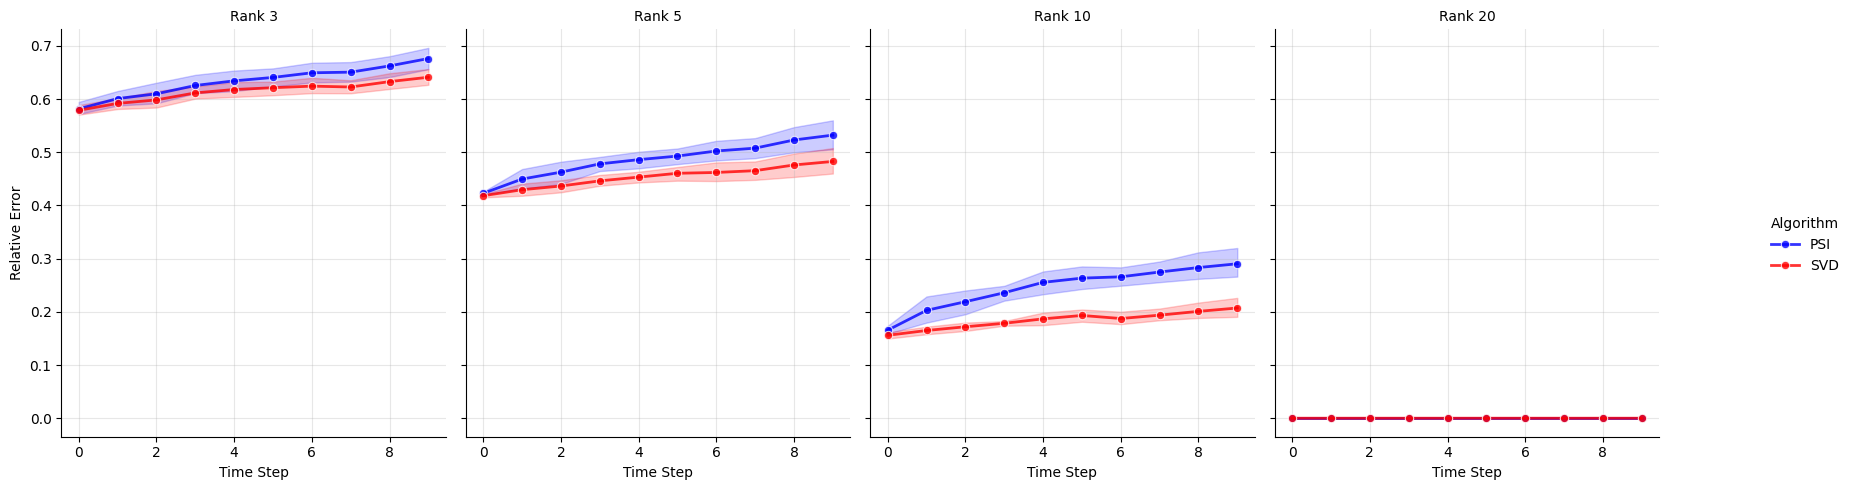

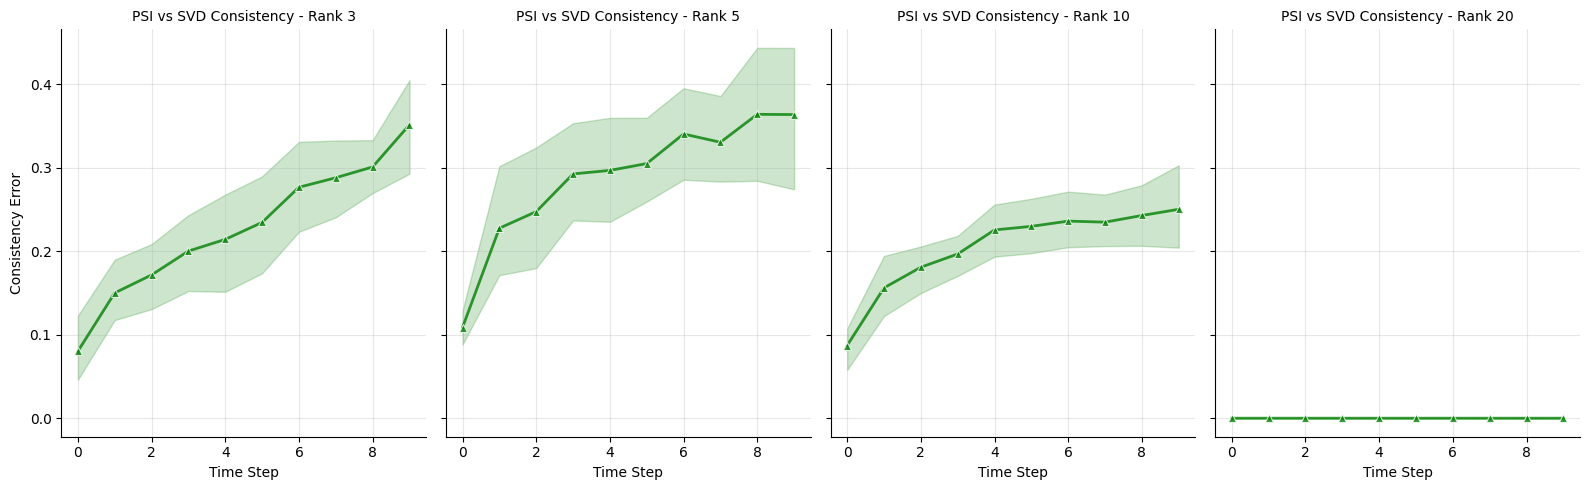

In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import sem, t

def reduce_rank_ps(delta_A, U_0, S_0, V_0):
    K_cur = U_0 @ S_0 + delta_A @ V_0
    U_cur, S_hat = torch.linalg.qr(K_cur)
    S_tild = S_hat - U_cur.T @ delta_A @ V_0
    L_cur = V_0 @ S_tild.T + delta_A.T @ U_cur
    V_cur, S_cur_T = torch.linalg.qr(L_cur)
    return U_cur, S_cur_T.T, V_cur

def test_dynamics_for_seaborn():
    """Test PSI and SVD and format data for Seaborn plotting."""
    m, n = 20, 20
    seeds = [0, 100, 42, 200, 300]
    ranks = [3, 5, 10, 20]
    num_steps = 10

    # Store all data in a list for DataFrame creation
    data_rows = []
    
    gt_matrix = torch.randn(m, ranks[-1]) @ torch.randn(ranks[-1], n)
    

    for r in ranks:
        
        for seed in seeds:
            torch.manual_seed(seed)
            
            # Initialize with rank-r matrix
            
            
            # Get initial rank-r SVD factors
            
            U_full, S_full, V_full = torch.linalg.svd(gt_matrix)
            U = U_full[:, :r]           # [m, r]
            S = torch.diag(S_full[:r])  # [r, r] 
            V = V_full.T[:, :r]         # [n, r]
            # U = U_full          # [m, r]
            # S = torch.diag(S_full)  # [r, r] 
            # V = V_full.T        # [n, r]
    

            gt_matrix_upd = gt_matrix.clone()

            for i, t in enumerate(torch.linspace(0, 1, num_steps)):

                noise = 0.01 * torch.randn(m, n)
                g = torch.randn(1, n)
                update = g.T @ g

                U, S, V = reduce_rank_ps(update, U, S, V)
                ps_recon = U @ S @ V.T


                gt_matrix_upd += update

                # SVD update
                U_full, S_full, V_full = torch.linalg.svd(gt_matrix_upd)
                
                non_nuls = list(filter(lambda x: x > 1e-9, S_full))
                true_rank = len(non_nuls)
                svd_recon = U_full[:, :r] @ torch.diag(S_full[:r]) @ V_full[:r, :]
                # svd_recon = U_full @ torch.diag(S_full) @ V_full
                # print(S_full)

                # Calculate errors
                psi_error = torch.norm(ps_recon - gt_matrix_upd).item() / torch.norm(gt_matrix_upd).item()
                svd_error = torch.norm(svd_recon - gt_matrix_upd).item() / torch.norm(gt_matrix_upd).item()
                consistency_error = torch.norm(ps_recon - svd_recon).item() / torch.norm(gt_matrix_upd).item()

                # Add PSI data
                data_rows.append({
                    'rank': r,
                    'seed': seed,
                    'step': i,
                    'algorithm': 'PSI',
                    'error': psi_error,
                    'error_type': 'vs_ground_truth'
                })
                
                # Add SVD data
                data_rows.append({
                    'rank': r,
                    'seed': seed,
                    'step': i,
                    'algorithm': 'SVD',
                    'error': svd_error,
                    'error_type': 'vs_ground_truth'
                })
                
                # Add consistency data
                data_rows.append({
                    'rank': r,
                    'seed': seed,
                    'step': i,
                    'algorithm': 'PSI vs SVD',
                    'error': consistency_error,
                    'error_type': 'consistency'
                })

    return pd.DataFrame(data_rows)

def plot_with_seaborn_facetgrid(df):
    """Plot using Seaborn FacetGrid with rank as columns and algorithm as hue."""
    
    # Filter for ground truth errors only (exclude consistency for cleaner plot)
    df_gt = df[df['error_type'] == 'vs_ground_truth'].copy()
    
    # Set up the color palette
    palette = {'PSI': 'blue', 'SVD': 'red'}

    # Alternative: Map with confidence intervals
    g = sns.FacetGrid(
        df_gt, 
        col='rank', 
        hue='algorithm',
        palette=palette,
        height=5, 
        aspect=0.8,
        col_wrap=None,
        legend_out=True
    )
    
    g.map_dataframe(
        sns.lineplot,
        x='step',
        y='error',
        marker='o',
        markersize=6,
        linewidth=2,
        alpha=0.8,
        err_style='band',  # This adds confidence intervals
        errorbar=('ci', 95)
    )
    
    # Customize the plot
    g.set_axis_labels('Time Step', 'Relative Error')
    g.set_titles('Rank {col_name}')
    
    # Add legend
    g.add_legend(title='Algorithm', bbox_to_anchor=(1.05, 0.5), loc='center left')
    
    # Add grid
    for ax in g.axes.flat:
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Create a second plot for consistency errors
    df_consistency = df[df['error_type'] == 'consistency'].copy()
    
    g2 = sns.FacetGrid(
        df_consistency, 
        col='rank',
        height=5, 
        aspect=0.8,
        col_wrap=None
    )
    
    g2.map_dataframe(
        sns.lineplot,
        x='step',
        y='error',
        marker='^',
        markersize=6,
        linewidth=2,
        color='green',
        alpha=0.8,
        err_style='band',
        errorbar=('ci', 95)
    )
    
    g2.set_axis_labels('Time Step', 'Consistency Error')
    g2.set_titles('PSI vs SVD Consistency - Rank {col_name}')
    
    for ax in g2.axes.flat:
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Usage
df = test_dynamics_for_seaborn()
plot_with_seaborn_facetgrid(df)
# plot_summary_statistics(df)
